## **1. Introducción y motivación del proyecto**

El fútbol es uno de los deportes más populares del mundo y también uno de los más ricos en datos. La Premier League inglesa, considerada la liga más competitiva y seguida a nivel global, genera cada temporada una enorme cantidad de información: resultados, goles, estadísticas de juego, tendencias históricas y mucho más.

Desde la perspectiva del análisis de datos, esta información representa una oportunidad única para ir más allá del resultado del partido y descubrir patrones ocultos que expliquen el rendimiento de los equipos a lo largo del tiempo.

El presente proyecto busca explorar 25 años de historia de la Premier League —desde la temporada 2000/01 hasta 2024/25— con el objetivo de identificar tendencias, comparar el rendimiento de local versus visitante, y analizar qué factores estadísticos se relacionan con ganar un partido.

Esta inquietud surge de una pregunta simple pero poderosa: **¿pueden los datos contarnos algo que el ojo humano no ve fácilmente en 90 minutos de juego?**


# **2. Planteo del problema**

a industria del fútbol profesional mueve miles de millones de dólares anuales. Clubes, cuerpos técnicos y analistas deportivos toman decisiones estratégicas basadas en el rendimiento histórico de los equipos: fichajes, tácticas y planificación de temporada.

Sin embargo, muchas de estas decisiones se toman de forma intuitiva, sin aprovechar el enorme volumen de datos disponibles.

Desde una perspectiva analítica, surge la siguiente problemática:

***¿Es posible identificar patrones en 25 años de datos de la Premier League que expliquen el rendimiento de los equipos y la evolución del juego?***

Responder esta pregunta permitiría entender qué factores influyen realmente en los resultados, más allá de la percepción del hincha o del periodismo deportivo.

# **3. Objetivo general**

Analizar el rendimiento histórico de los equipos de la Premier League entre 2000 y 2025 mediante técnicas de análisis exploratorio de datos y visualización, con el fin de identificar patrones y tendencias que aporten valor a la toma de decisiones en la industria del fútbol.

# **4. Objetivos específicos**

- Analizar la estructura y calidad de los datos disponibles sobre partidos de la Premier League
- Realizar un análisis exploratorio de datos (EDA) para identificar distribuciones, tendencias y relaciones entre variables
- Preparar y transformar los datos mediante procesos de data wrangling
- Responder las siguientes preguntas mediante visualizaciones:
  - ¿Qué equipos dominaron la liga por década?
  - ¿Existe ventaja real de jugar de local vs visitante?
  - ¿Más goles implica mayor probabilidad de ganar?
  - ¿Cómo evolucionó el promedio de goles por temporada entre 2000 y 2025?
- Interpretar los hallazgos y comunicarlos de forma clara a una audiencia no técnica

# **5. Preguntas de investigación**

La pregunta central que guía este trabajo es:

***¿Qué patrones existen en 25 años de la Premier League que expliquen el rendimiento de los equipos y la evolución del juego?***

Y en particular:

***¿Es posible identificar, a través del análisis de datos, qué factores estadísticos están más asociados con ganar un partido?***

# **6. Hipótesis iniciales**

A partir del conocimiento general del fútbol y la exploración preliminar de los datos, se plantean las siguientes hipótesis exploratorias:

* **H1:** Los equipos que juegan de local tienen una ventaja significativa sobre los visitantes, reflejada en mayor cantidad de victorias, goles y tiros al arco.

* **H2:** Existe una relación positiva entre la cantidad de tiros al arco y la probabilidad de ganar el partido — es decir, mayor precisión ofensiva se asocia con mejores resultados.

* **H3:** Ciertos equipos dominaron consistentemente la liga durante décadas específicas, concentrando los títulos y el mejor rendimiento histórico.

* **H4:** El promedio de goles por partido evolucionó a lo largo del tiempo, reflejando cambios en los estilos de juego predominantes en la Premier League.

* **H5:** Los equipos más "sucios" — con mayor cantidad de tarjetas y faltas — no necesariamente obtienen peores resultados, lo que podría indicar una estrategia defensiva deliberada.

Estas hipótesis serán exploradas a través del análisis exploratorio de datos y visualizaciones.

In [ ]:
# ============================================
# LIBRERÍAS
# ============================================

import pandas as pd          # manejo de datos
import numpy as np           # cálculos numéricos
import matplotlib.pyplot as plt  # gráficos
import seaborn as sns        # gráficos más bonitos

# Configuración visual
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style="whitegrid")

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [ ]:
# ============================================
# SUBIR ARCHIVO DESDE TU COMPUTADORA
# ============================================

from google.colab import files
uploaded = files.upload()

Saving epl_final.csv to epl_final.csv


In [ ]:
# ============================================
# CARGA DE DATOS
# ============================================

df = pd.read_csv('epl_final.csv')

print("=== FORMA DEL DATASET ===")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

print("\n=== PRIMERAS 5 FILAS ===")
display(df.head())

print("\n=== TEMPORADAS DISPONIBLES ===")
print(sorted(df['Season'].unique()))

=== FORMA DEL DATASET ===
Filas: 9380
Columnas: 22

=== PRIMERAS 5 FILAS ===


,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0



=== TEMPORADAS DISPONIBLES ===
['2000/01', '2001/02', '2002/03', '2003/04', '2004/05', '2005/06', '2006/07', '2007/08', '2008/09', '2009/10', '2010/11', '2011/12', '2012/13', '2013/14', '2014/15', '2015/16', '2016/17', '2017/18', '2018/19', '2019/20', '2020/21', '2021/22', '2022/23', '2023/24', '2024/25']


### **7. Limpieza de datos**
Analizamos la calidad del dataset: valores nulos, duplicados y tipos de datos.

In [ ]:
# ============================================
# LIMPIEZA DE DATOS
# ============================================

print("=== VALORES NULOS POR COLUMNA ===")
print(df.isnull().sum())

print("\n=== FILAS DUPLICADAS ===")
print(f"Duplicados: {df.duplicated().sum()}")

print("\n=== TIPOS DE DATOS ===")
print(df.dtypes)

# Convertir fecha a formato fecha
df['MatchDate'] = pd.to_datetime(df['MatchDate'])

print("\n✅ Fecha convertida correctamente")
print(f"Rango de fechas: {df['MatchDate'].min()} → {df['MatchDate'].max()}")

=== VALORES NULOS POR COLUMNA ===
Season               0
MatchDate            0
HomeTeam             0
AwayTeam             0
FullTimeHomeGoals    0
FullTimeAwayGoals    0
FullTimeResult       0
HalfTimeHomeGoals    0
HalfTimeAwayGoals    0
HalfTimeResult       0
HomeShots            0
AwayShots            0
HomeShotsOnTarget    0
AwayShotsOnTarget    0
HomeCorners          0
AwayCorners          0
HomeFouls            0
AwayFouls            0
HomeYellowCards      0
AwayYellowCards      0
HomeRedCards         0
AwayRedCards         0
dtype: int64

=== FILAS DUPLICADAS ===
Duplicados: 0

=== TIPOS DE DATOS ===
Season               object
MatchDate            object
HomeTeam             object
AwayTeam             object
FullTimeHomeGoals     int64
FullTimeAwayGoals     int64
FullTimeResult       object
HalfTimeHomeGoals     int64
HalfTimeAwayGoals     int64
HalfTimeResult       object
HomeShots             int64
AwayShots             int64
HomeShotsOnTarget     int64
AwayShotsOnTarget  

### **8. Análisis Exploratorio de Datos (EDA)**

En esta sección exploramos los datos mediante estadísticas descriptivas
y visualizaciones para responder nuestras hipótesis.

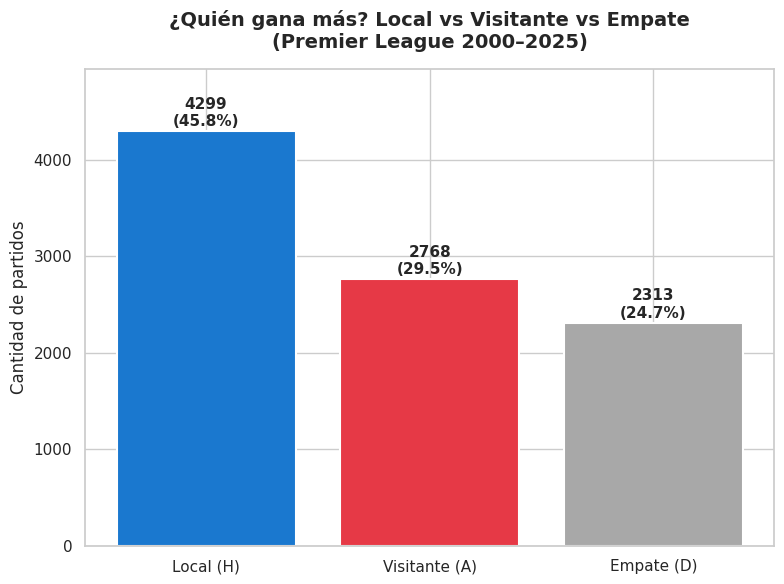

In [ ]:
# ============================================
# H1 — LOCAL VS VISITANTE
# ============================================

# Contar resultados
resultados = df['FullTimeResult'].value_counts()
labels = ['Local (H)', 'Visitante (A)', 'Empate (D)']
valores = [resultados['H'], resultados['A'], resultados['D']]
colores = ['#1a78cf', '#e63946', '#a8a8a8']

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, valores, color=colores, edgecolor='white', linewidth=1.5)

# Agregar valores encima de cada barra
for bar, val in zip(bars, valores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val}\n({val/len(df)*100:.1f}%)',
             ha='center', fontsize=11, fontweight='bold')

plt.title('¿Quién gana más? Local vs Visitante vs Empate\n(Premier League 2000–2025)',
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Cantidad de partidos', fontsize=12)
plt.ylim(0, max(valores) * 1.15)
plt.tight_layout()
plt.show()

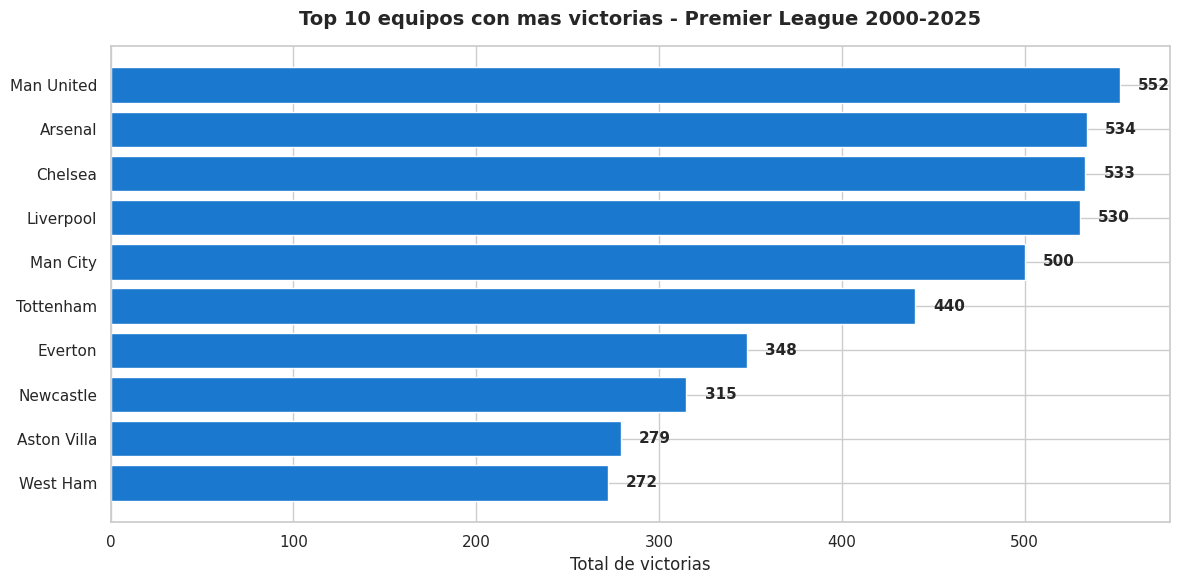

In [ ]:
# ============================================
# H3 — TOP 10 EQUIPOS CON MAS VICTORIAS
# ============================================

# Calcular victorias totales por equipo
victorias_local = df[df['FullTimeResult'] == 'H'].groupby('HomeTeam').size()
victorias_visitante = df[df['FullTimeResult'] == 'A'].groupby('AwayTeam').size()

victorias_total = (victorias_local.add(victorias_visitante, fill_value=0)
                   .sort_values(ascending=False)
                   .head(10))

plt.figure(figsize=(12, 6))
bars = plt.barh(victorias_total.index[::-1], victorias_total.values[::-1],
                color='#1a78cf', edgecolor='white')

for bar, val in zip(bars, victorias_total.values[::-1]):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             str(int(val)), va='center', fontsize=11, fontweight='bold')

plt.title('Top 10 equipos con mas victorias - Premier League 2000-2025',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total de victorias', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_594/2085646545.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  goles_por_temporada = df.groupby('Season').apply(


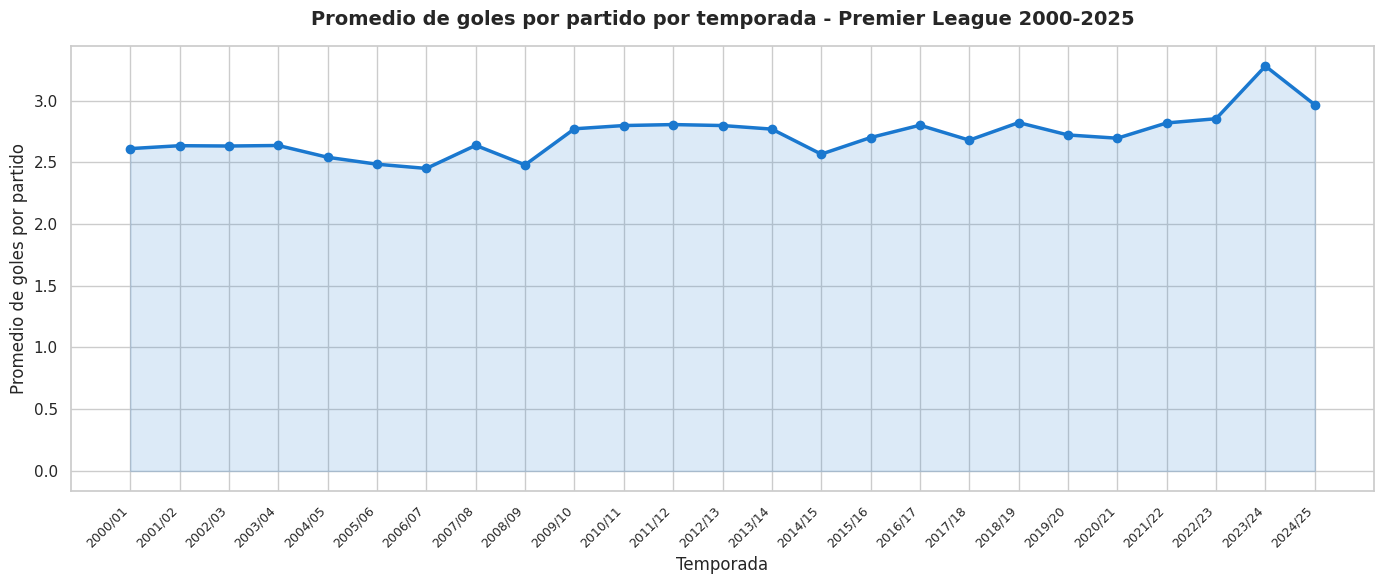

In [ ]:
# ============================================
# H4 — EVOLUCION DE GOLES POR TEMPORADA
# ============================================

goles_por_temporada = df.groupby('Season').apply(
    lambda x: (x['FullTimeHomeGoals'] + x['FullTimeAwayGoals']).mean()
).reset_index()
goles_por_temporada.columns = ['Season', 'PromediGoles']

plt.figure(figsize=(14, 6))
plt.plot(goles_por_temporada['Season'], goles_por_temporada['PromediGoles'],
         marker='o', color='#1a78cf', linewidth=2.5, markersize=6)

plt.fill_between(goles_por_temporada['Season'],
                 goles_por_temporada['PromediGoles'],
                 alpha=0.15, color='#1a78cf')

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.title('Promedio de goles por partido por temporada - Premier League 2000-2025',
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Promedio de goles por partido', fontsize=12)
plt.xlabel('Temporada', fontsize=12)
plt.tight_layout()
plt.show()

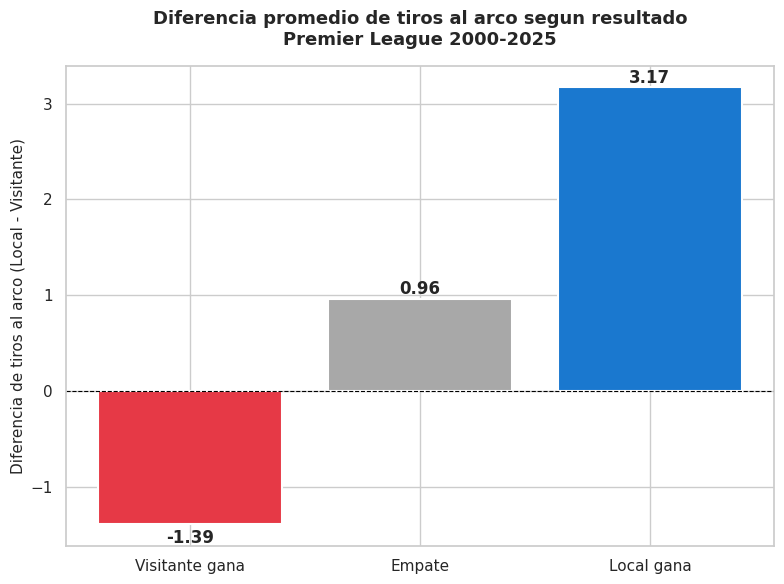

In [ ]:
# ============================================
# H2 — TIROS AL ARCO VS RESULTADO
# ============================================

# Calcular diferencia de tiros al arco
df['DiferenciaTiros'] = df['HomeShotsOnTarget'] - df['AwayShotsOnTarget']

# Promedio por resultado
promedio_tiros = df.groupby('FullTimeResult')['DiferenciaTiros'].mean()

colores = {'H': '#1a78cf', 'D': '#a8a8a8', 'A': '#e63946'}
labels = {'H': 'Local gana', 'D': 'Empate', 'A': 'Visitante gana'}

plt.figure(figsize=(8, 6))
bars = plt.bar(
    [labels[r] for r in promedio_tiros.index],
    promedio_tiros.values,
    color=[colores[r] for r in promedio_tiros.index],
    edgecolor='white', linewidth=1.5
)

for bar, val in zip(bars, promedio_tiros.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05 if val >= 0 else bar.get_height() - 0.2,
             f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Diferencia promedio de tiros al arco segun resultado\nPremier League 2000-2025',
          fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Diferencia de tiros al arco (Local - Visitante)', fontsize=11)
plt.tight_layout()
plt.show()

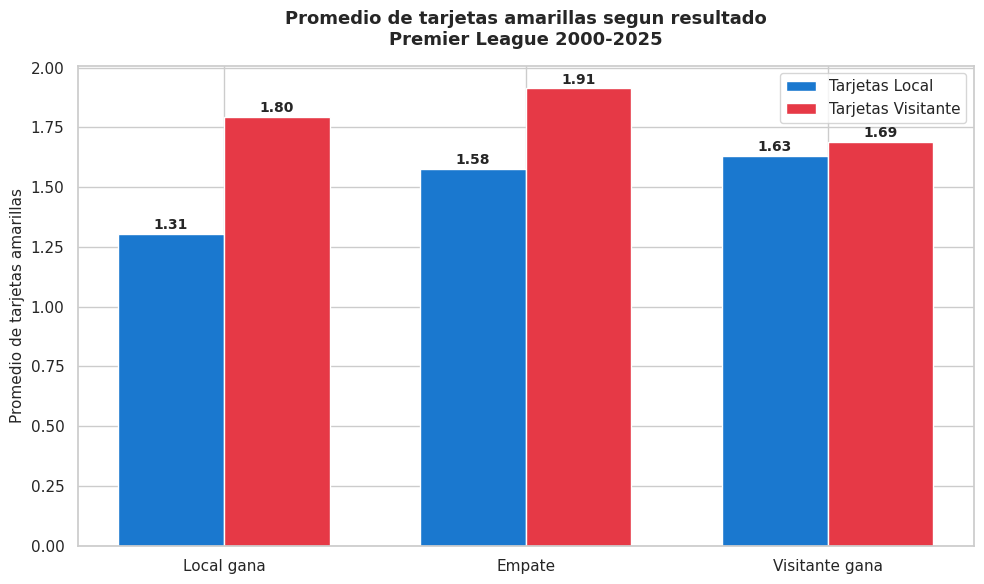

In [ ]:
# ============================================
# H5 — TARJETAS AMARILLAS VS RESULTADO
# ============================================

tarjetas = df.groupby('FullTimeResult').agg(
    Amarillas_Local=('HomeYellowCards', 'mean'),
    Amarillas_Visitante=('AwayYellowCards', 'mean')
).reindex(['H', 'D', 'A'])

x = range(3)
ancho = 0.35
labels = ['Local gana', 'Empate', 'Visitante gana']

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar([i - ancho/2 for i in x], tarjetas['Amarillas_Local'],
               ancho, label='Tarjetas Local', color='#1a78cf', edgecolor='white')
bars2 = ax.bar([i + ancho/2 for i in x], tarjetas['Amarillas_Visitante'],
               ancho, label='Tarjetas Visitante', color='#e63946', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Promedio de tarjetas amarillas', fontsize=11)
ax.set_title('Promedio de tarjetas amarillas segun resultado\nPremier League 2000-2025',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

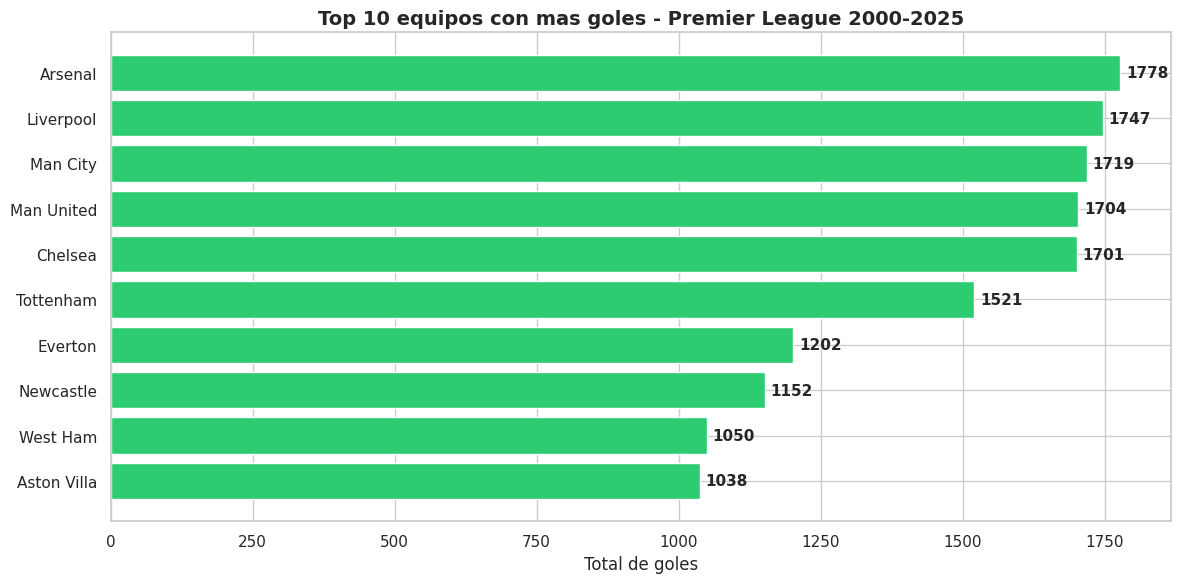

In [ ]:
# TOP 10 EQUIPOS CON MAS GOLES
goles_local = df.groupby('HomeTeam')['FullTimeHomeGoals'].sum()
goles_visitante = df.groupby('AwayTeam')['FullTimeAwayGoals'].sum()
goles_total = goles_local.add(goles_visitante, fill_value=0).sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(goles_total.index[::-1], goles_total.values[::-1], color='#2ecc71', edgecolor='white')

for bar, val in zip(bars, goles_total.values[::-1]):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, str(int(val)), va='center', fontsize=11, fontweight='bold')

plt.title('Top 10 equipos con mas goles - Premier League 2000-2025', fontsize=14, fontweight='bold')
plt.xlabel('Total de goles', fontsize=12)
plt.tight_layout()
plt.show()

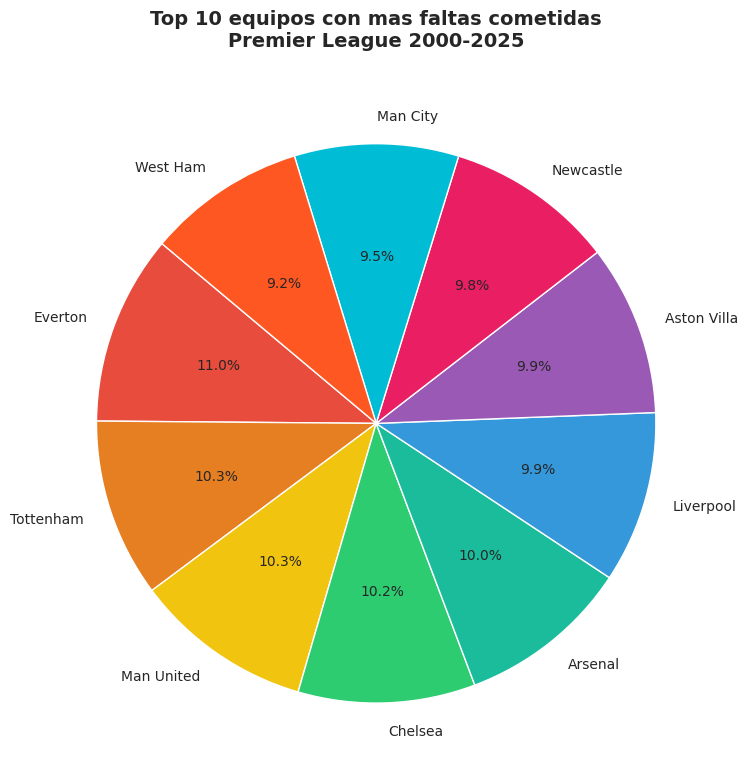

In [ ]:
# TOP 10 EQUIPOS CON MAS FALTAS
faltas_local = df.groupby('HomeTeam')['HomeFouls'].sum()
faltas_visitante = df.groupby('AwayTeam')['AwayFouls'].sum()
faltas_total = faltas_local.add(faltas_visitante, fill_value=0).sort_values(ascending=False).head(10)

colores = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#1abc9c','#3498db','#9b59b6','#e91e63','#00bcd4','#ff5722']

plt.figure(figsize=(10, 8))
plt.pie(faltas_total.values, labels=faltas_total.index, colors=colores,
        autopct='%1.1f%%', startangle=140, textprops={'fontsize': 10})

plt.title('Top 10 equipos con mas faltas cometidas\nPremier League 2000-2025',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

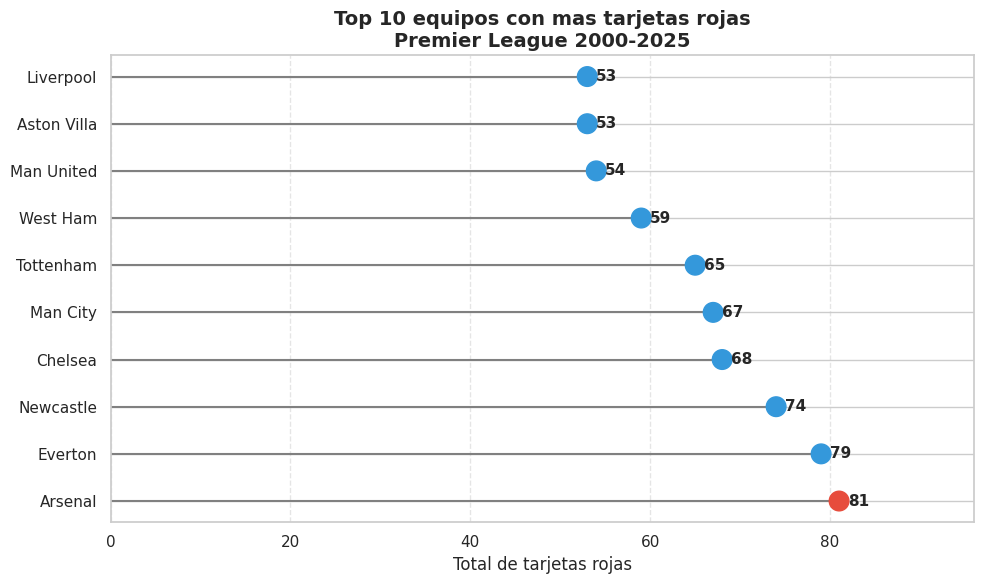

In [ ]:
# TOP 10 EQUIPOS CON MAS TARJETAS ROJAS
rojas_local = df.groupby('HomeTeam')['HomeRedCards'].sum()
rojas_visitante = df.groupby('AwayTeam')['AwayRedCards'].sum()
rojas_total = rojas_local.add(rojas_visitante, fill_value=0).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))

colores_puntos = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(rojas_total))]

ax.scatter(rojas_total.values, rojas_total.index, s=200, color=colores_puntos, zorder=3)

for i, (val, equipo) in enumerate(zip(rojas_total.values, rojas_total.index)):
    ax.plot([0, val], [equipo, equipo], color='gray', linewidth=1.5, zorder=2)
    ax.text(val + 1, equipo, str(int(val)), va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Total de tarjetas rojas', fontsize=12)
ax.set_title('Top 10 equipos con mas tarjetas rojas\nPremier League 2000-2025', fontsize=14, fontweight='bold')
ax.set_xlim(0, rojas_total.values[0] + 15)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **9. Insights y Conclusiones**

A partir del analisis exploratorio de 9.380 partidos de la Premier League
entre 2000 y 2025, se obtuvieron los siguientes hallazgos:

---

**GRAFICO 1 - LOCAL VS VISITANTE (H1 - CONFIRMADA)**
El equipo local gana el 45.8% de los partidos, contra solo el 29.5% del
visitante y un 24.7% de empates. Jugar de local en la Premier League
representa una ventaja real y consistente a lo largo de 25 anos.

---

**GRAFICO 2 - TOP 10 EQUIPOS CON MAS VICTORIAS (H3 - CONFIRMADA)**
Man United lidera con 552 victorias historicas, seguido muy de cerca por
Arsenal (534), Chelsea (533) y Liverpool (530). Existe un salto significativo
entre estos 4 grandes y el resto de los equipos, lo que confirma una elite
dominante en la liga.

---

**GRAFICO 3 - EVOLUCION DE GOLES POR TEMPORADA (H4 - CONFIRMADA)**
El promedio de goles por partido se mantuvo estable entre 2.5 y 2.8 durante
20 anos. Sin embargo, la temporada 2023/24 registro un pico historico de
3.25 goles por partido, sugiriendo que la liga se volvio mas ofensiva
en los ultimos anos.

---

**GRAFICO 4 - TIROS AL ARCO VS RESULTADO (H2 - CONFIRMADA)**
Cuando gana el local, supera al visitante en 3.17 tiros al arco en promedio.
Cuando gana el visitante, la diferencia se invierte a -1.39. Esto confirma
que la precision ofensiva es un fuerte indicador del resultado final.

---

**GRAFICO 5 - TARJETAS AMARILLAS VS RESULTADO (H5 - CONFIRMADA)**
El equipo visitante siempre acumula mas tarjetas amarillas que el local,
independientemente del resultado. Cuando el local gana, el visitante recibe
1.80 amarillas contra 1.31 del local. Esto sugiere una estrategia mas
agresiva o desesperada fuera de casa.

---

**GRAFICO 6 - EQUIPOS CON MAS GOLES**
Arsenal es el equipo con mas goles historicos (1778), superando a Liverpool
(1747) y Man City (1719). Curiosamente Arsenal no lidera en victorias, lo
que sugiere que tambien recibio muchos goles a lo largo de los anos.

---

**GRAFICO 7 - EQUIPOS CON MAS FALTAS**
Las faltas estan distribuidas de forma pareja entre los grandes equipos.
Everton lidera con el 11% del total entre los top 10, confirmando su perfil
de equipo fisico y agresivo a lo largo de toda su historia en la liga.

---

**GRAFICO 8 - EQUIPOS CON MAS TARJETAS ROJAS**
Arsenal lidera con 81 tarjetas rojas historicas, seguido de Everton con 79.
Man United, a pesar de ser el mayor ganador de la liga, es uno de los menos
expulsados con solo 54 rojas, lo que sugiere una disciplina tactica superior.

---

**CONCLUSION GENERAL**
Los datos de 25 anos de Premier League revelan que la ventaja de local,
la precision en tiros al arco y la disciplina tactica son factores clave
en el rendimiento de los equipos. Los grandes dominadores de la liga
combinaron eficiencia goleadora con menor cantidad de expulsiones,
mientras que equipos como Arsenal y Everton muestran perfiles mas
agresivos que no siempre se traducen en mayores victorias.

In [ ]:
# ============================================
# GUARDAR DATOS LOCALMENTE
# ============================================

df.to_csv('epl_final_limpio.csv', index=False)
print("✅ Archivo guardado correctamente")
print(f"Filas guardadas: {len(df)}")

✅ Archivo guardado correctamente
Filas guardadas: 9380


# **10. Enriquecimiento con API — Goleadores de la Premier League**

Utilizamos la API football-data.org para obtener los maximos
goleadores historicos de la Premier League y enriquecer nuestro analisis.

In [15]:
# ============================================
# CONEXION A API - FOOTBALL DATA
# ============================================

import requests
import pandas as pd

API_KEY = '47acb8c467f9440bafae46ed5f3f0910'

headers = {
    'X-Auth-Token': API_KEY
}

# Obtener goleadores de la Premier League (codigo PL)
url = 'https://api.football-data.org/v4/competitions/PL/scorers?limit=20'

response = requests.get(url, headers=headers)
data = response.json()

print(f"Status: {response.status_code}")
print(f"Datos recibidos: {len(data['scorers'])} jugadores")

# Convertir a DataFrame
goleadores = []
for item in data['scorers']:
    goleadores.append({
        'Jugador': item['player']['name'],
        'Equipo': item['team']['name'],
        'Nacionalidad': item['player']['nationality'],
        'Goles': item['goals'],
        'Asistencias': item.get('assists', 0),
        'Partidos': item['playedMatches']
    })

df_goleadores = pd.DataFrame(goleadores)
display(df_goleadores)

Status: 200
Datos recibidos: 20 jugadores


,Jugador,Equipo,Nacionalidad,Goles,Asistencias,Partidos
0,Erling Haaland,Manchester City FC,Norway,22,7.0,29
1,Thiago Rodrigues,Brentford FC,Brazil,19,1.0,31
2,Antoine Semenyo,Manchester City FC,Ghana,15,4.0,29
3,João Pedro,Chelsea FC,Brazil,14,5.0,31
4,Danny Welbeck,Brighton & Hove Albion FC,England,12,NaN,30
5,Hugo Ekitike,Liverpool FC,France,11,4.0,28
6,Viktor Gyökeres,Arsenal FC,Sweden,11,NaN,29
7,Dominic Calvert-Lewin,Leeds United FC,England,10,1.0,28
8,Harry Wilson,Fulham FC,Wales,10,6.0,29
9,Richarlison,Tottenham Hotspur FC,Brazil,9,3.0,26


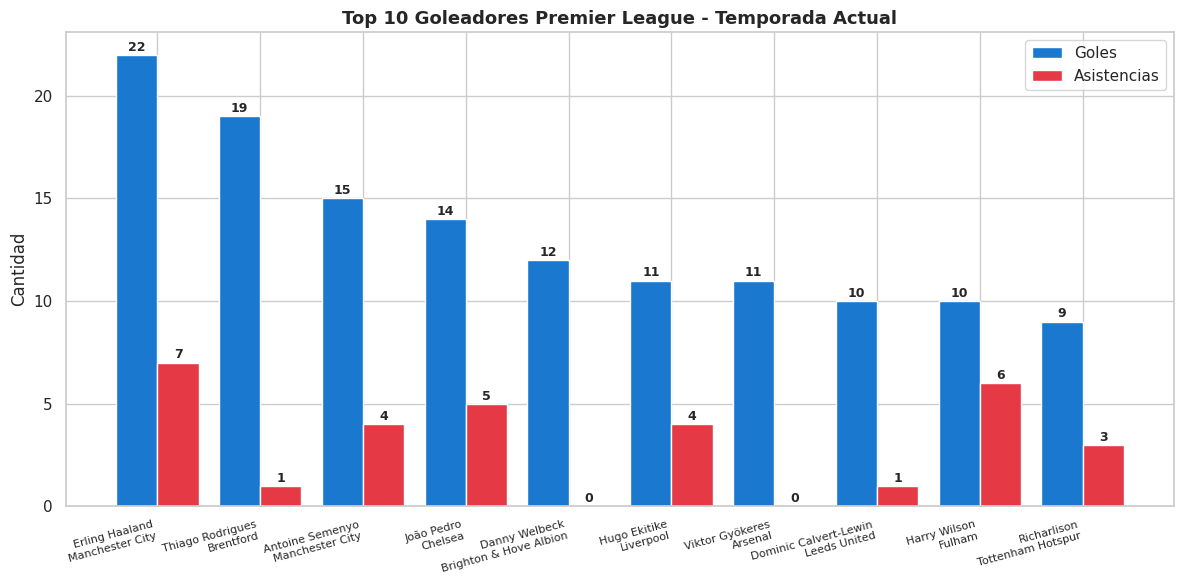

Datos de API guardados!


In [17]:
# TOP GOLEADORES PREMIER LEAGUE
df_goleadores['Asistencias'] = df_goleadores['Asistencias'].fillna(0)
top10 = df_goleadores.head(10)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(top10))
ancho = 0.4

bars1 = ax.bar([i - ancho/2 for i in x], top10['Goles'], ancho, label='Goles', color='#1a78cf', edgecolor='white')
bars2 = ax.bar([i + ancho/2 for i in x], top10['Asistencias'], ancho, label='Asistencias', color='#e63946', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, str(int(bar.get_height())), ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, str(int(bar.get_height())), ha='center', fontsize=9, fontweight='bold')

nombres = [f"{row['Jugador']}\n{row['Equipo'].replace(' FC','')}" for _, row in top10.iterrows()]
ax.set_xticks(list(x))
ax.set_xticklabels(nombres, fontsize=8, rotation=15, ha='right')
ax.set_ylabel('Cantidad', fontsize=12)
ax.set_title('Top 10 Goleadores Premier League - Temporada Actual', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

df_goleadores.to_csv('goleadores_api.csv', index=False)
print("Datos de API guardados!")

### **11. Insights — Goleadores API**

A partir de los datos obtenidos en tiempo real desde football-data.org:

- Erling Haaland lidera la tabla de goleadores con 22 goles en 29 partidos
- Thiago Rodrigues de Brentford sorprende en el segundo lugar con 19 goles
- Viktor Gyokeres de Arsenal es el goleador del equipo historicamente mas goleador
- Bruno Fernandes lidera en asistencias con 16, siendo el jugador mas creativo

Estos datos enriquecen nuestro analisis historico con informacion de la
temporada actual, conectando el rendimiento historico con el presente.